In [1]:
import os
from tqdm import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.integrate import cumulative_trapezoid
from scipy.special import jv
from scipy.interpolate import RegularGridInterpolator, interp1d
from astropy import constants as con
from astropy import units as u

import BaryonForge as bfg
import pyccl as ccl

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=1.8)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

os.environ["PK_MODEL"] = "BCEmu7"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
os.environ["DIR_PATH"] = "data/frb_results"
os.environ["SAMPLE"] = "frb_sample"
os.environ["SAMPLE_EXTENDED"] = "Yes"
from mcmc_funcs import *
from sensitivity_funcs import *


Not using emulators.
Unknown Pk_model!


In [2]:
# Constants
c = con.c.to('km/s').value
Mpc_in_cm = (1 * u.Mpc).to(u.cm).value
sigma_T = 6.65e-25 # cm^2
m_e = 9.10938e-28  # g
c_cgs = con.c.cgs.value

# Cosmological parameters from Planck18
from astropy.cosmology import Planck18 as cosmo
H0_kms_per_Mpc = cosmo.H0.value
Om0 = cosmo.Om0
Ob0 = cosmo.Ob0
sigma8 = 0.8111


class SourceDistribution:
    """
    Handles source redshift distribution n(z) and computes lensing efficiency kernel W(z).
    """
    def __init__(self, cosmo_calc, nz_file, zmin=1e-4, zmax=3.0, zbin_k_idx1=4, zbin_k_idx2=4):
        self.cosmo = cosmo_calc
        self.zmin = zmin
        self.zmax = zmax
        self.zbin_k_idx1 = zbin_k_idx1
        self.zbin_k_idx2 = zbin_k_idx2
        self.z_grid = np.linspace(zmin, zmax, 100)

        self._load_nz(nz_file)
        self._compute_W_z()

    def _load_nz(self, nz_file):
        """Load n(z) from file, interpolate, and normalize."""
        data = np.loadtxt(nz_file)
        zbins = data[:, 0]
        self.dn2d_dz_k1 = np.interp(self.z_grid, zbins, data[:, self.zbin_k_idx1])
        self.dn2d_dz_k2 = np.interp(self.z_grid, zbins, data[:, self.zbin_k_idx2])
        self.dn2d_dz_k1 = np.clip(self.dn2d_dz_k1, 0.0, None)
        self.dn2d_dz_k2 = np.clip(self.dn2d_dz_k2, 0.0, None)
        self.dn2d_dz_k1 /= np.trapz(self.dn2d_dz_k1, self.z_grid)
        self.dn2d_dz_k2 /= np.trapz(self.dn2d_dz_k2, self.z_grid)

        self.Hz = self.cosmo.H_z(self.z_grid)
        self.chi = self.cosmo.chi(self.z_grid)

    def _compute_W_z(self):
        """
        Compute lensing efficiency kernel W_k(z) for sources with n_k(z).
        """
        z = self.z_grid              # shape (nz,)
        chi = self.chi               # comoving distance at z, shape (nz,)
        Hz = self.Hz                 # H(z) at z, shape (nz,)
        n_k_z1 = self.dn2d_dz_k1     # n(z') per unit redshift, shape (nz,)  (or (nbin,nz))
        n_k_z2 = self.dn2d_dz_k2
        
        # scale factor a(z)
        a = 1.0 / (1.0 + z)

        # prefactor: 3 H0^2 Omega_m chi(z) / (2 c^2 a(z))
        H0_over_c = (self.cosmo.H0 / self.cosmo.c)
        prefactor = 1.5 * self.cosmo.Om0 * (H0_over_c**2) * chi / a

        # make 2D grids: source (chi', z') along axis=0, lens (chi, z) along axis=1
        chi_s, chi_l = np.meshgrid(chi, chi, indexing='ij')
        z_s,   z_l   = np.meshgrid(z, z, indexing='ij')    

        n_s_z_interp1 = np.interp(z_s, z, n_k_z1)  # shape (nz, nz)
        n_s_z_interp2 = np.interp(z_s, z, n_k_z2)

        # geometry factor: (chi' - chi)/chi'
        eps = 1e-30
        geom = (chi_s - chi_l) / np.where(chi_s == 0.0, eps, chi_s)

        # only sources behind lens contribute: use z' >= z
        integrand1 = n_s_z_interp1 * geom
        integrand1 = np.where(z_s >= z_l, integrand1, 0.0)
        integrand2 = n_s_z_interp2 * geom
        integrand2 = np.where(z_s >= z_l, integrand2, 0.0)

        # integrate over z' (trapz uses z spacing) -> no extra Jacobian factor
        # final lensing kernel
        self.W_k_wt1 = prefactor * np.trapz(integrand1, z, axis=0)
        self.W_k_wt2 = prefactor * np.trapz(integrand2, z, axis=0)

        self.W_tSZ_wt = (1+z)**2 # 1/(1+z) # tSZ weight function


class AngularPowerSpectrumCalculator:
    """
    Computes angular power spectrum C_ell and w(theta) from W(z) and P(k,z).
    """
    def __init__(self, cosmo_calc, src_dist, lmin=1, lmax=500, logMmax=16):
        self.cosmo = cosmo_calc
        self.src_dist = src_dist
        self.lmin = int(lmin)
        self.lmax = int(lmax)
        self.logMmax = logMmax

        self.k_fields = np.geomspace(1e-4, 1e6, 1000)
        self.z_grid = self.src_dist.z_grid

        self.get_power_spectra({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=self.logMmax)
        self.compute_Cell()
    
    def get_power_spectra_BCEmu1(self, log_Mc, z_arr, log10M_max=16, log10M_min=6):
        Ob0 = self.cosmo.Ob0
        Om0 = self.cosmo.Om0
        h = self.cosmo.h

        mass_def=ccl.halos.massdef.MassDef200c
        c_M_relation = ccl.halos.concentration.ConcentrationDiemer15

        fft_precision = dict(padding_lo_fftlog=1e-8, padding_hi_fftlog=1e8, n_per_decade=100)

        ccl_cosmo = ccl.Cosmology(Omega_c=Om0-Ob0, Omega_b=Ob0, h=h,
                                  sigma8=0.8111, n_s=0.9665, matter_power_spectrum='linear')
        self.ccl_cosmo = ccl_cosmo

        P_MP = []; P_MM = []
        for i in (range(len(z_arr))):
            z = z_arr[i]
            rho = ccl.rho_x(ccl_cosmo, 1/(1+z), 'matter', is_comoving=True)
            par = dict(theta_ej=4.93, theta_co=0.1, M_c=(10**12.84)/h, mu_beta=0.94, 
                   eta=0.22, eta_delta=0.21, tau=-1.5, tau_delta=0, A=0.055/2, 
                   M1=2.5e11/h, epsilon_h=0.015, a=0.3, n=2, epsilon=4, p=0.3, 
                   q=0.707, gamma=2.79, delta=7.33)
            
            DMO = bfg.Profiles.Schneider19.DarkMatter(**par, r_min_int=1e-3, r_max_int=1e2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
            GAS = bfg.Profiles.Schneider19.Gas(**par, r_min_int=1e-3, r_max_int=1e2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
            STR = bfg.Profiles.Schneider19.Stars(**par, r_min_int=1e-6, r_max_int=5, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
            CLM = bfg.Profiles.Schneider19.CollisionlessMatter(**par, max_iter=2, reltol=5e-2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
            DMB = bfg.Profiles.Schneider19.DarkMatterBaryon(**par,
                                                            gas=GAS, stars=STR, collisionlessmatter=CLM, darkmatter=DMO,
                                                            twohalo=bfg.Profiles.misc.Zeros(), 
                                                            r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)    
            PRS = bfg.Profiles.Thermodynamic.ElectronPressure(gas = GAS, darkmatterbaryon = DMB)
            
            DMB = DMB / rho

            for p in [DMB, PRS]:
                p.update_precision_fftlog(**fft_precision)

            HMC_flex = HMCalculator_NoCorrection(mass_function='Tinker08', halo_bias='Tinker10',
                                                 mass_def=mass_def,
                                                 log10M_min=9, log10M_max=log10M_max, nM=100)

            P_MP.append(ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), DMB, prof2=PRS, suppress_1h=lambda k: 1e-2, get_2h=False))
            P_MM.append(ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), DMB, suppress_1h=lambda k: 1e-2, get_2h=False))
         
        P_MP = np.array(P_MP)
        P_MM = np.array(P_MM)
        
        P_MP[np.isnan(P_MP)] = 1e-30
        P_MM[np.isnan(P_MM)] = 1e-30
        
        factor = Mpc_in_cm * sigma_T/(m_e*c_cgs**2)
        self.P_MP = P_MP*factor
        self.P_MM = P_MM
        
    def get_power_spectra(self, fp, Pk_model="BCEmu1", log10M_max=16, log10M_min=6):
        if Pk_model == "BCEmu1":
            self.get_power_spectra_BCEmu1(fp["log_Mc"], self.z_grid, log10M_max, log10M_min)
        else:
            raise ValueError("Unknown Pk_model!")

    def compute_Cell(self):
        """Compute angular power spectrum C_ell via Limber approximation."""
        z_grid = self.z_grid
        Hz_grid = self.src_dist.Hz
        chi_grid = self.src_dist.chi
        logk_grid = np.log10(self.k_fields)
        ells = np.arange(self.lmin, self.lmax + 1); self.ell = ells; n_ell = len(ells)
        
        W_k_z1 = self.src_dist.W_k_wt1
        W_k_z2 = self.src_dist.W_k_wt2
        W_tSZ_z = self.src_dist.W_tSZ_wt
        # Smooth kernels near z=0 to avoid spikes
        eps = 1  # number of first points to smooth
        for W in [W_k_z1, W_k_z2, W_tSZ_z]:
            W[:eps] = W[:eps] * np.linspace(0, 1, eps)
        
        # z(chi) and kernels W(z) as function of chi
        z_of_chi = interp1d(chi_grid, z_grid, bounds_error=False, fill_value=(z_grid[0], z_grid[-1]))
        
        # for z-integrand
        pts_z = np.repeat(z_grid[None, :], len(ells), axis=0)
        k_grid = ((ells[:, None]+0.5) / chi_grid[None, :])
        pts_logk = np.log10(k_grid)
        pts_z = np.stack([np.log10(pts_z.ravel()), pts_logk.ravel()], axis=-1)
        
        self.k_array = np.geomspace(1e-2, 1e2, 100); n_k = len(self.k_array)
        # for k-integrand
        chi_ellk = (ells[:, None]+0.5) / self.k_array[None, :]
        # Optionally mask chi > chi_H or chi <= 0 (outside domain): chi_H = chi_grid[-1]
        mask_outside = (chi_ellk <= 0) | (chi_ellk > chi_grid[-1])
        z_ellk = z_of_chi(chi_ellk.ravel()).reshape(n_ell, n_k)
        pts_k = np.stack([np.log10(z_ellk.ravel()), np.log10(self.k_array.repeat(n_ell, axis=0).ravel())], axis=-1)
        
        def calculate_Cell(W1, W2, P):
            logP_interpolator = RegularGridInterpolator((np.log10(z_grid), logk_grid), np.log10(P), bounds_error=False, fill_value=-30)
            
            # for z-integrand
            logP_vals = logP_interpolator(pts_z).reshape(len(ells), len(z_grid)); logP_vals[np.isnan(logP_vals)] = -30
            Pk_values_Mpc3 = (10.0**logP_vals)
            integrand_z = (W1[None, :] * W2[None, :] / chi_grid[None, :]**2) * Pk_values_Mpc3 * (c / Hz_grid[None, :])
            
            if self.logMmax == 16: # compute k-integrand for dC/dk derivatives only when logMmax=16
                W1_interp_fn = interp1d(chi_grid, W1, bounds_error=False, fill_value=0.0)
                W2_interp_fn = interp1d(chi_grid, W2, bounds_error=False, fill_value=0.0)

                W1_ellk = W1_interp_fn(chi_ellk.ravel()).reshape(n_ell, n_k)
                W2_ellk = W2_interp_fn(chi_ellk.ravel()).reshape(n_ell, n_k)
                logP_vals = logP_interpolator(pts_k).reshape(n_ell, n_k)
                Pk_values_Mpc3 = (10.0**logP_vals)
                integrand_k = (W1_ellk * W2_ellk / (ells + 0.5)[:, None]) * Pk_values_Mpc3
                integrand_k[mask_outside] = 0.0 # mask outside domain -> set integrand to 0 there
                return integrand_z, integrand_k, np.trapz(integrand_z, z_grid, axis=1)
            else:
                return np.trapz(integrand_z, z_grid, axis=1)
    
        if self.logMmax == 16: # store k-integrand and z-integrand for dC/dk and dC/dz derivatives only when logMmax=16
            self.dC_ell_ky_dz1, self.dC_ell_ky_dk1, self.C_ell_ky1 = calculate_Cell(W_k_z1, W_tSZ_z, self.P_MP)
            self.dC_ell_kk_dz12, self.dC_ell_kk_dk12, self.C_ell_kk12 = calculate_Cell(W_k_z1, W_k_z2, self.P_MM)
            if self.src_dist.zbin_k_idx1 != self.src_dist.zbin_k_idx2:
                self.dC_ell_ky_dz2, self.dC_ell_ky_dk2, self.C_ell_ky2 = calculate_Cell(W_k_z2, W_tSZ_z, self.P_MP)
        else:
            self.C_ell_ky1 = calculate_Cell(W_k_z1, W_tSZ_z, self.P_MP)
            self.C_ell_kk12 = calculate_Cell(W_k_z1, W_k_z2, self.P_MM)
            if self.src_dist.zbin_k_idx1 != self.src_dist.zbin_k_idx2:
                self.C_ell_ky2 = calculate_Cell(W_k_z2, W_tSZ_z, self.P_MP)

    def _compute_xi_theta(self):
        """Compute real-space correlation function w(theta) via Hankel transform (J2)."""
        theta_deg = np.logspace(-2, np.log10(5.), 100); self.theta = theta_deg*60 # arcmin

        self.xi_theta_ky = ccl.correlation(self.ccl_cosmo, ell=self.ell, C_ell=self.C_ell_ky, theta=theta_deg, type='NG', method='FFTLog')
        self.xi_theta_kk_plus = ccl.correlation(self.ccl_cosmo, ell=self.ell, C_ell=self.C_ell_kk, theta=theta_deg, type='GG+', method='FFTLog')
        self.xi_theta_kk_minus = ccl.correlation(self.ccl_cosmo, ell=self.ell, C_ell=self.C_ell_kk, theta=theta_deg, type='GG-', method='FFTLog')

        

In [3]:
nz_file = 'data/sensitivity/source_DESY3.txt'
zmin, zmax = 1e-7, 2
zbin_k_idx1, zbin_k_idx2 = 4, 4 # DES redshift bin index
lmin, lmax = 1, 20000

# instantiate cosmology helper
cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=H0_kms_per_Mpc, Ob0=Ob0, Om0=Om0, sigma8=sigma8)

# load source distribution and compute W(z)
src_dist = SourceDistribution(cosmo_calc, nz_file=nz_file, zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2)

# compute C_ell and w_theta
aps = AngularPowerSpectrumCalculator(cosmo_calc, src_dist, lmin=lmin, lmax=lmax, logMmax=16)
ell = aps.ell


In [4]:
from joblib import Parallel, delayed

# zbin_k_idx1, zbin_k_idx2 = 1, 1 # DES redshift bin index
logMmaxs = np.linspace(10, 16, 100)
# src_dist = SourceDistribution(cosmo_calc, nz_file=nz_file, zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2)

# def run_one(logMmax):
#     power_spectra_object = AngularPowerSpectrumCalculator(
#         cosmo_calc, src_dist, lmin=lmin, lmax=lmax, logMmax=logMmax
#     )
#     dict_object = {
#         "C_ell_ky1": power_spectra_object.C_ell_ky1,
#         "C_ell_kk12": power_spectra_object.C_ell_kk12
#     }
#     if zbin_k_idx1 != zbin_k_idx2:
#         dict_object["C_ell_ky2"] = power_spectra_object.C_ell_ky2
#     if logMmax==16:
#         dict_object["dC_ell_ky_dz1"] = power_spectra_object.dC_ell_ky_dz1,
#         dict_object["dC_ell_ky_dk1"] = power_spectra_object.dC_ell_ky_dk1,
#         if zbin_k_idx1 != zbin_k_idx2:
#             dict_object["dC_ell_ky_dz2"] = power_spectra_object.dC_ell_ky_dz2,
#             dict_object["dC_ell_ky_dk2"] = power_spectra_object.dC_ell_ky_dk2,
#         dict_object["dC_ell_kk_dz12"] = power_spectra_object.dC_ell_kk_dz12,
#         dict_object["dC_ell_kk_dk12"] = power_spectra_object.dC_ell_kk_dk12
#     return dict_object

# power_spectra_object = Parallel(n_jobs=6)(
#     delayed(run_one)(logMmaxs[i]) for i in tqdm(range(len(logMmaxs)))
# )

# np.save("data/sensitivity_analysis/power_spectra_object_bins{}{}_only1halo_lmax2e4_DES_bestfit.npy".format(zbin_k_idx1, zbin_k_idx2), power_spectra_object, allow_pickle=True)


In [5]:
zbins = aps.z_grid
order = [11,21,31,41,22,32,42,33,43,44]
C_ell_kk, dC_ell_kk_dz, dC_ell_kk_dk = [], [], []
for ij in order:
    C_ell_kk_temp, dC_ell_kk_dz_temp, dC_ell_kk_dk_temp = [], [], []
    power_spectra_object = np.load("data/sensitivity/power_spectra_object_bins{}_1h.npy".format(ij), allow_pickle=True)
    for k in range(len(logMmaxs)):
        C_ell_kk_temp.append(power_spectra_object[k]["C_ell_kk12"])
        if k==99:
            dC_ell_kk_dz_temp.append(np.array(power_spectra_object[k]["dC_ell_kk_dz12"])[0])
            dC_ell_kk_dk_temp.append(np.array(power_spectra_object[k]["dC_ell_kk_dk12"]))
    C_ell_kk.append(C_ell_kk_temp)
    dC_ell_kk_dz.append(np.array(dC_ell_kk_dz_temp)[0])
    dC_ell_kk_dk.append(np.array(dC_ell_kk_dk_temp)[0])
    
C_ell_kk = np.transpose(C_ell_kk, (0, 2, 1))
dC_ell_kk_dz = np.array(dC_ell_kk_dz)
dC_ell_kk_dk = np.array(dC_ell_kk_dk)
np.shape(C_ell_kk), np.shape(dC_ell_kk_dz), np.shape(dC_ell_kk_dk)


((10, 20000, 100), (10, 20000, 100), (10, 20000, 100))

In [6]:
theta_edges= np.logspace(np.log10(2.5),np.log10(250),num=21)
data_theta =np.sqrt(theta_edges[:-1]*theta_edges[1:])

data = np.loadtxt('data/sensitivity/DESY3_shear_optimized.mask')
shear_mask = ~(data[:, 1].astype(bool))
shear_mask = np.ones(np.shape(shear_mask)).astype(bool)

#read in DES measurement
datavfile = 'data/sensitivity/DESY3_shear.txt'
d = np.genfromtxt(datavfile)[:,1]
covfile = 'data/sensitivity/DESY3_cov_shear.txt'
ndata = d.shape[0]
shear_cov = np.zeros((ndata,ndata))
data = np.genfromtxt(covfile)
for i in range(0,data.shape[0]):
    shear_cov[int(data[i,0]),int(data[i,1])] = data[i,2]
    shear_cov[int(data[i,1]),int(data[i,0])] = data[i,2]


In [7]:
_, _, dC_ell_kk_dM = np.gradient(C_ell_kk, order, ell, logMmaxs, edge_order=2)

dxi_theta_kk_plus_dM, dxi_theta_kk_plus_dz = [], []
for i in tqdm(range(len(order))):
    dxi_theta_kk_plus_dM.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_kk_dM[i, :, j], theta=data_theta/60, type='GG+', method='FFTLog') for j in (range(len(logMmaxs)))]))
    dxi_theta_kk_plus_dz.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_kk_dz[i, :, j], theta=data_theta/60, type='GG+', method='FFTLog') for j in (range(len(logMmaxs)))]))

dxi_theta_kk_plus_dM = np.transpose(dxi_theta_kk_plus_dM, (1, 0, 2)).reshape(100, 200)[:, :200]
dxi_theta_kk_plus_dz = np.transpose(dxi_theta_kk_plus_dz, (1, 0, 2)).reshape(100, 200)[:, :200]



ind = np.arange(200,400)
mask = np.array(shear_mask)[ind]
cov = shear_cov[np.ix_(ind[mask], ind[mask])]

dxi_theta_kk_minus_dM, dxi_theta_kk_minus_dz = [], []
for i in tqdm(range(len(order))):
    dxi_theta_kk_minus_dM.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_kk_dM[i, :, j], theta=data_theta/60, type='GG-', method='FFTLog') for j in (range(len(logMmaxs)))]))
    dxi_theta_kk_minus_dz.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_kk_dz[i, :, j], theta=data_theta/60, type='GG-', method='FFTLog') for j in (range(len(logMmaxs)))]))

dxi_theta_kk_minus_dM = np.transpose(dxi_theta_kk_minus_dM, (1, 0, 2)).reshape(100, 200)[:, 0:200]
dxi_theta_kk_minus_dz = np.transpose(dxi_theta_kk_minus_dz, (1, 0, 2)).reshape(100, 200)[:, 0:200]



100%|█████████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.57it/s]


Text(0.5, 1.0, 'DES: $\\xi^{kk}_\\pm$')

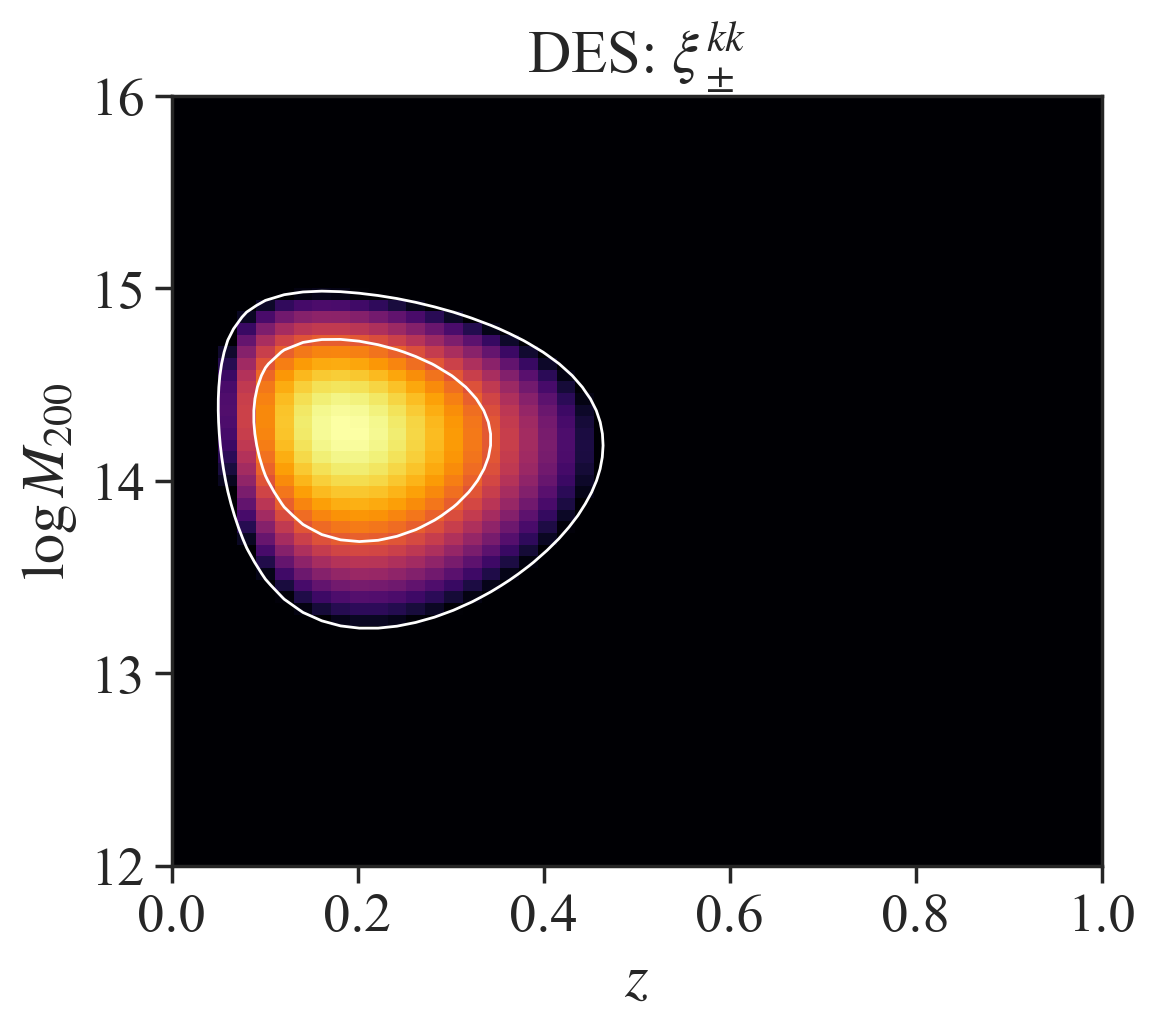

In [8]:
dxi_theta_kk_dM = np.concatenate((dxi_theta_kk_plus_dM, dxi_theta_kk_minus_dM), axis=1)
dxi_theta_kk_dz = np.concatenate((dxi_theta_kk_plus_dz, dxi_theta_kk_minus_dz), axis=1)

ind = np.arange(0,400)
mask = np.array(shear_mask)[ind]
cov = shear_cov[np.ix_(ind[mask], ind[mask])]

sensitivity = dxi_theta_kk_dM[:, mask] @ np.linalg.inv(cov) @ dxi_theta_kk_dz.T[mask, :]
sensitivity /= np.max(sensitivity)
sensitivity[sensitivity<1e-3] = 1e-10

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(zbins, logMmaxs, sensitivity, shading="nearest", cmap="inferno", norm=LogNorm(0.33*np.max(sensitivity), 1*np.max(sensitivity)))

levels = np.array([0.33, 0.66])
Z, M = np.meshgrid(zbins, logMmaxs)
contours = ax.contour(Z, M, sensitivity/np.max(sensitivity), levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("$z$")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_xlim(0, 1)
ax.set_ylim(12, 16)

ax.set_title(r'DES: $\xi^{kk}_\pm$')

# np.save("data/sensitivity/sensitivity_DES_xi_pm_MZ.npy", np.array([Z, M, sensitivity/np.max(sensitivity)]))


In [9]:
dC_ell_kk_dk[dC_ell_kk_dk == 0] = 1e-40

dxi_theta_kk_plus_dk = []
for i in tqdm(range(len(order))):
    dxi_theta_kk_plus_dk.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_kk_dk[i, :, j], theta=data_theta/60, type='GG+', method='FFTLog') for j in (range(len(logMmaxs)))]))
    
dxi_theta_kk_plus_dk = np.transpose(dxi_theta_kk_plus_dk, (1, 0, 2)).reshape(100, 200)


ind = np.arange(200,400)
mask = np.array(shear_mask)[ind]
cov = shear_cov[np.ix_(ind[mask], ind[mask])]

dxi_theta_kk_minus_dk = []
for i in tqdm(range(len(order))):
    dxi_theta_kk_minus_dk.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_kk_dk[i, :, j], theta=data_theta/60, type='GG-', method='FFTLog') for j in (range(len(logMmaxs)))]))

dxi_theta_kk_minus_dk = np.transpose(dxi_theta_kk_minus_dk, (1, 0, 2)).reshape(100, 200)



100%|█████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.06it/s]


Text(0.5, 1.0, 'DES: $\\xi^{kk}_\\pm$')

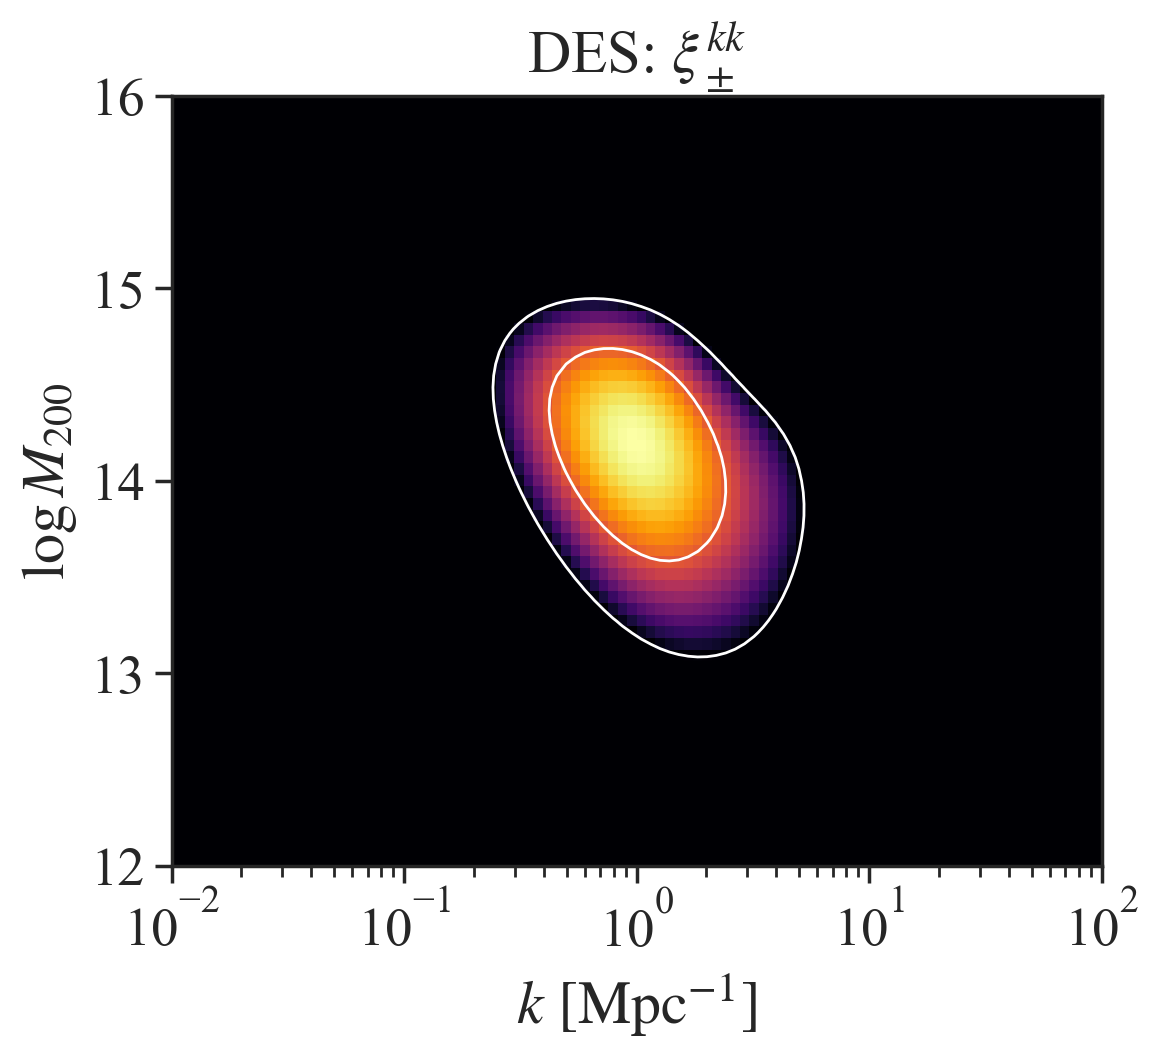

In [10]:
dxi_theta_kk_dM = np.concatenate((dxi_theta_kk_plus_dM, dxi_theta_kk_minus_dM), axis=1)
dxi_theta_kk_dk = np.concatenate((dxi_theta_kk_plus_dk, dxi_theta_kk_minus_dk), axis=1)

ind = np.arange(0,400)
mask = np.array(shear_mask)[ind]
cov = shear_cov[np.ix_(ind[mask], ind[mask])]

sensitivity = dxi_theta_kk_dM[:, mask] @ np.linalg.inv(cov) @ dxi_theta_kk_dk.T[mask, :]
sensitivity /= np.max(sensitivity)
sensitivity[sensitivity<1e-3] = 1e-10

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(aps.k_array, logMmaxs, sensitivity, shading="nearest", cmap="inferno", norm=LogNorm(0.33, 1))

levels = np.array([0.33, 0.66])
Z, M = np.meshgrid(aps.k_array, logMmaxs)
contours = ax.contour(Z, M, sensitivity, levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("$k~[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_ylim(12, 16)
ax.set_xlim(1e-2, 1e2)
ax.set_xscale('log')

ax.set_title(r'DES: $\xi^{kk}_\pm$')

# np.save("data/sensitivity/sensitivity_DES_xi_pm_MK.npy", np.array([Z, M, sensitivity/np.max(sensitivity)]))


In [11]:
order = [11,22,33,44]
C_ell_ky, dC_ell_ky_dz, dC_ell_ky_dk = [], [], []
for ij in order:
    C_ell_ky_temp, dC_ell_ky_dz_temp, dC_ell_ky_dk_temp = [], [], []
    power_spectra_object = np.load("data/sensitivity/power_spectra_object_bins{}_1h.npy".format(ij), allow_pickle=True) 
    for k in range(len(logMmaxs)):
        C_ell_ky_temp.append(power_spectra_object[k]["C_ell_ky1"])
        if k==99:
            dC_ell_ky_dz_temp.append(np.array(power_spectra_object[k]["dC_ell_ky_dz1"])[0])
            dC_ell_ky_dk_temp.append(np.array(power_spectra_object[k]["dC_ell_ky_dk1"]))
    C_ell_ky.append(C_ell_ky_temp)
    dC_ell_ky_dz.append(np.array(dC_ell_ky_dz_temp)[0])
    dC_ell_ky_dk.append(np.array(dC_ell_ky_dk_temp)[0,0])
    
C_ell_ky = np.transpose(C_ell_ky, (0, 2, 1))
dC_ell_ky_dz = np.array(dC_ell_ky_dz)
dC_ell_ky_dk = np.array(dC_ell_ky_dk)
np.shape(C_ell_ky), np.shape(dC_ell_ky_dz), np.shape(dC_ell_ky_dk)


((4, 20000, 100), (4, 20000, 100), (4, 20000, 100))

In [12]:
import pickle
class RenameUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core")
        return super().find_class(module, name)

with open("data/sensitivity/DESxACT_gty_xip_xim_DV_ilc_SZ_yy_maskedPS.pk", "rb") as f:
    data_DES_ACT = RenameUnpickler(f).load()

shear_tSZ_cov = data_DES_ACT['cov_total'][:80, :80]
shear_tSZ_theta = data_DES_ACT['theta_all'][:80]


100%|███████████████████████████████████████████████████████████████████| 4/4 [00:02<00:00,  1.66it/s]


Text(0.5, 1.0, 'ACT x DES: $\\xi^{ky}$')

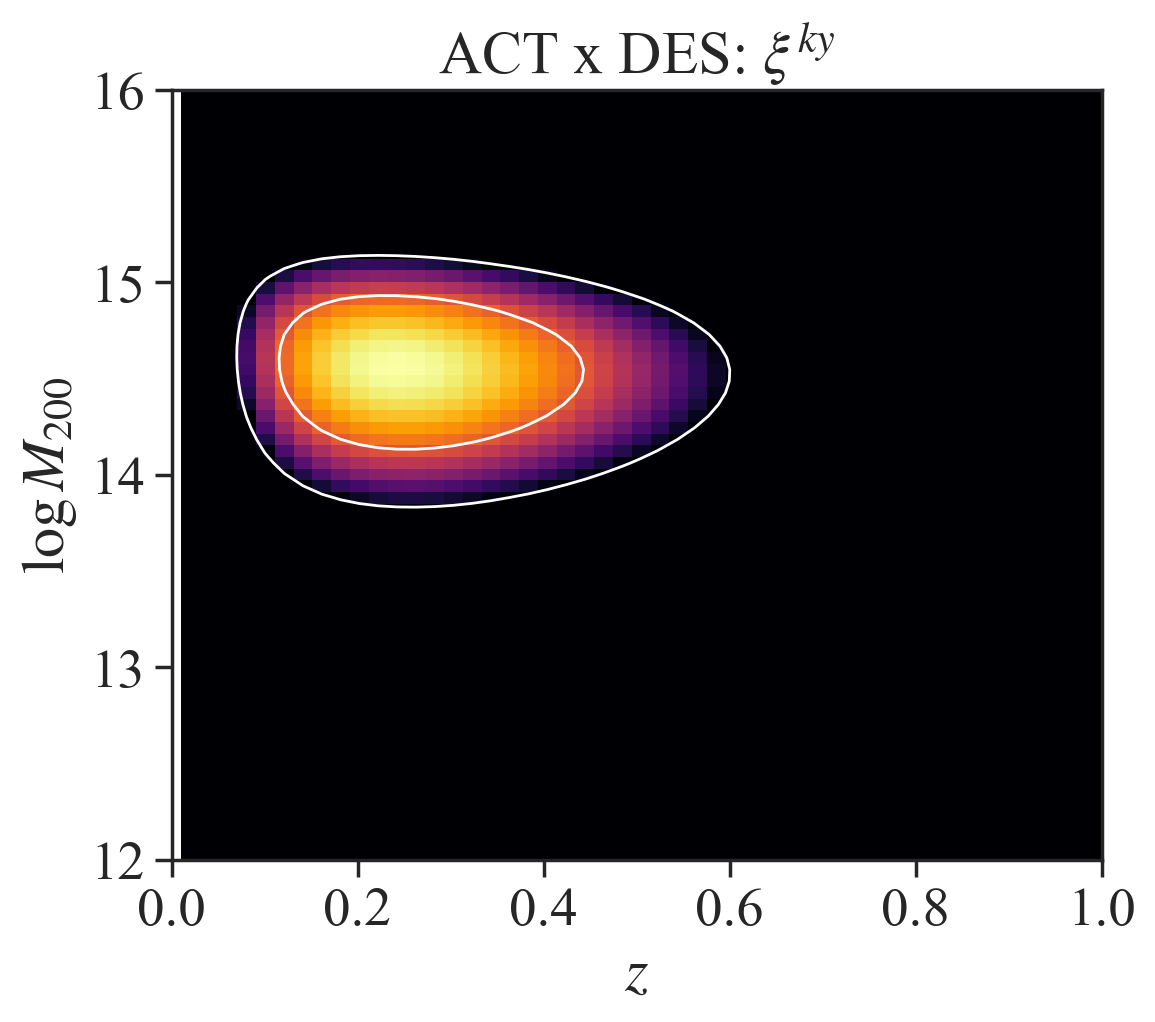

In [13]:
_, _, dC_ell_ky_dM = np.gradient(C_ell_ky, order, ell, logMmaxs, edge_order=2)
dC_ell_ky_dM[dC_ell_ky_dM<0] = 1e-100

dxi_theta_ky_dM, dxi_theta_ky_dz = [], []
for i in tqdm(range(len(order))):
    dxi_theta_ky_dM.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_ky_dM[i, :, j], theta=shear_tSZ_theta[i*20: (i+1)*20]/60, type='NG', method='FFTLog') for j in (range(len(logMmaxs)))]))
    dxi_theta_ky_dz.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_ky_dz[i, :, j], theta=shear_tSZ_theta[i*20: (i+1)*20]/60, type='NG', method='FFTLog') for j in (range(len(logMmaxs)))]))

dxi_theta_ky_dM = np.transpose(dxi_theta_ky_dM, (1, 0, 2)).reshape(100, 80)
dxi_theta_ky_dz = np.transpose(dxi_theta_ky_dz, (1, 0, 2)).reshape(100, 80)

sensitivity = dxi_theta_ky_dM @ np.linalg.inv(shear_tSZ_cov) @ dxi_theta_ky_dz.T
sensitivity /= np.max(sensitivity)
sensitivity = np.abs(sensitivity)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(zbins, logMmaxs, sensitivity, shading="nearest", cmap="inferno", norm=LogNorm(0.33, 1))

levels = np.array([0.33, 0.66])
Z, M = np.meshgrid(zbins, logMmaxs)
contours = ax.contour(Z, M, sensitivity, levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("$z$")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_xlim(0, 1)
ax.set_ylim(12, 16)

ax.set_title(r'ACT x DES: $\xi^{ky}$')

# np.save("data/sensitivity/sensitivity_DES_ACT_xi_MZ.npy", np.array([Z, M, sensitivity/np.max(sensitivity)]))


100%|███████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.40it/s]


Text(0.5, 1.0, 'ACT x DES: $\\xi^{ky}$')

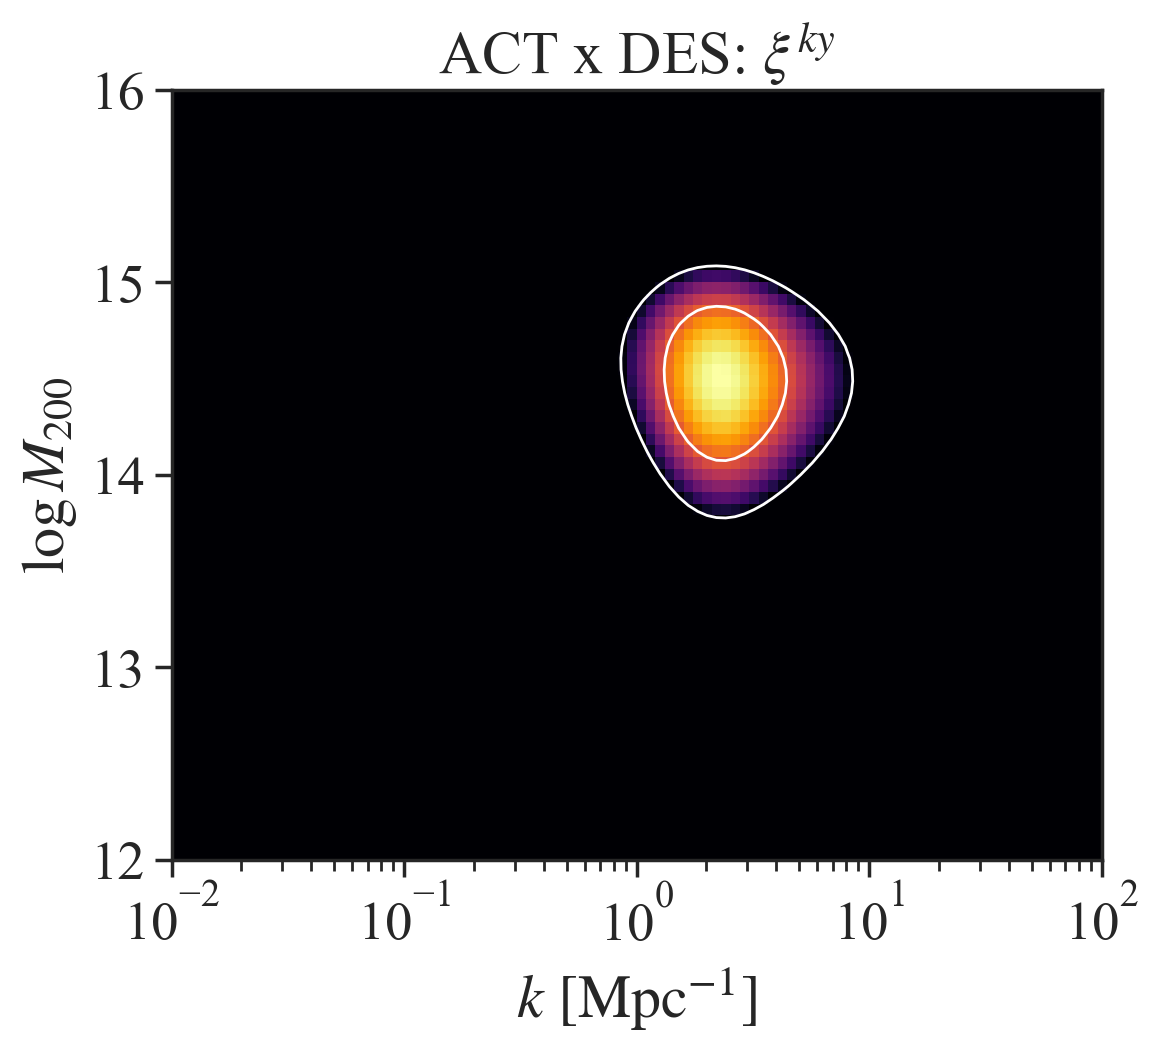

In [14]:
dC_ell_ky_dk[dC_ell_ky_dk == 0] = 1e-40

dxi_theta_ky_dk = []
for i in tqdm(range(len(order))):
    dxi_theta_ky_dk.append(np.array([
        ccl.correlation(aps.ccl_cosmo, ell=aps.ell, C_ell=dC_ell_ky_dk[i, :, j], theta=shear_tSZ_theta[i*20: (i+1)*20]/60, type='NG', method='FFTLog') for j in (range(len(logMmaxs)))]))

dxi_theta_ky_dk = np.transpose(dxi_theta_ky_dk, (1, 0, 2)).reshape(100, 80)

sensitivity = dxi_theta_ky_dM @ np.linalg.inv(shear_tSZ_cov) @ dxi_theta_ky_dk.T
sensitivity /= np.max(sensitivity)
sensitivity[sensitivity<1e-3] = 1e-10

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(aps.k_array, logMmaxs, sensitivity, shading="nearest", cmap="inferno", norm=LogNorm(0.33*np.max(sensitivity), 1*np.max(sensitivity)))

levels = np.array([0.33, 0.66])
Z, M = np.meshgrid(aps.k_array, logMmaxs)
contours = ax.contour(Z, M, sensitivity/np.max(sensitivity), levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("$k~[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_ylim(12, 16)
ax.set_xlim(1e-2, 1e2)
ax.set_xscale('log')

ax.set_title(r'ACT x DES: $\xi^{ky}$')

# np.save("data/sensitivity_analysis/sensitivity_DES_ACT_xi_MK.npy", np.array([Z, M, sensitivity/np.max(sensitivity)]))
